## Himalayan Expeditions - Exploratory Data Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

peaks = pd.read_csv('../data/peaks.csv')
expeditions = pd.read_csv('../data/expeditions.csv')
members = pd.read_csv('../data/members.csv')

print(f'Peaks: {len(peaks)} rows, {peaks.shape[1]} cols')
print(f'Expeditions: {len(expeditions)} rows, {expeditions.shape[1]} cols')
print(f'Members: {len(members)} rows, {members.shape[1]} cols')

Peaks: 468 rows, 8 cols
Expeditions: 10364 rows, 16 cols
Members: 76519 rows, 21 cols


### 1. Data overview and quality

In [4]:
print('=== PEAKS ===')
print(peaks.dtypes)
print(f'\nMissing values:\n{peaks.isnull().sum()}')
peaks.head()

=== PEAKS ===
peak_id                        object
peak_name                      object
peak_alternative_name          object
height_metres                   int64
climbing_status                object
first_ascent_year             float64
first_ascent_country           object
first_ascent_expedition_id     object
dtype: object

Missing values:
peak_id                         0
peak_name                       0
peak_alternative_name         223
height_metres                   0
climbing_status                 0
first_ascent_year             132
first_ascent_country          132
first_ascent_expedition_id    135
dtype: int64


,peak_id,peak_name,peak_alternative_name,height_metres,climbing_status,first_ascent_year,first_ascent_country,first_ascent_expedition_id
0,AMAD,Ama Dablam,Amai Dablang,6814,Climbed,1961.0,"New Zealand, USA, UK",AMAD61101
1,AMPG,Amphu Gyabjen,NaN,5630,Climbed,1953.0,UK,AMPG53101
2,ANN1,Annapurna I,NaN,8091,Climbed,1950.0,France,ANN150101
3,ANN2,Annapurna II,NaN,7937,Climbed,1960.0,"UK, Nepal",ANN260101
4,ANN3,Annapurna III,NaN,7555,Climbed,1961.0,India,ANN361101


In [5]:
print('=== EXPEDITIONS ===')
print(expeditions.dtypes)
print(f'\nMissing values:\n{expeditions.isnull().sum()}')
expeditions.head()

=== EXPEDITIONS ===
expedition_id          object
peak_id                object
peak_name              object
year                    int64
season                 object
basecamp_date          object
highpoint_date         object
termination_date       object
termination_reason     object
highpoint_metres      float64
members                 int64
member_deaths           int64
hired_staff             int64
hired_staff_deaths      int64
oxygen_used              bool
trekking_agency        object
dtype: object

Missing values:
expedition_id            0
peak_id                  0
peak_name                1
year                     0
season                   0
basecamp_date         1095
highpoint_date         650
termination_date      2380
termination_reason       0
highpoint_metres       414
members                  0
member_deaths            0
hired_staff              0
hired_staff_deaths       0
oxygen_used              0
trekking_agency       1710
dtype: int64


,expedition_id,peak_id,peak_name,year,season,basecamp_date,highpoint_date,termination_date,termination_reason,highpoint_metres,members,member_deaths,hired_staff,hired_staff_deaths,oxygen_used,trekking_agency
0,ANN260101,ANN2,Annapurna II,1960,Spring,1960-03-15,1960-05-17,NaN,Success (main peak),7937.0,10,0,9,0,True,NaN
1,ANN269301,ANN2,Annapurna II,1969,Autumn,1969-09-25,1969-10-22,1969-10-26,Success (main peak),7937.0,10,0,0,0,False,NaN
2,ANN273101,ANN2,Annapurna II,1973,Spring,1973-03-16,1973-05-06,NaN,Success (main peak),7937.0,6,0,8,0,False,NaN
3,ANN278301,ANN2,Annapurna II,1978,Autumn,1978-09-08,1978-10-02,1978-10-05,"Bad weather (storms, high winds)",7000.0,2,0,0,0,False,NaN
4,ANN279301,ANN2,Annapurna II,1979,Autumn,NaN,1979-10-18,1979-10-20,"Bad weather (storms, high winds)",7160.0,3,0,0,0,False,NaN


In [6]:
print('=== MEMBERS ===')
print(members.dtypes)
print(f'\nMissing values:\n{members.isnull().sum()}')
members.head()

=== MEMBERS ===
expedition_id            object
member_id                object
peak_id                  object
peak_name                object
year                      int64
season                   object
sex                      object
age                     float64
citizenship              object
expedition_role          object
hired                      bool
highpoint_metres        float64
success                    bool
solo                       bool
oxygen_used                bool
died                       bool
death_cause              object
death_height_metres     float64
injured                    bool
injury_type              object
injury_height_metres    float64
dtype: object

Missing values:
expedition_id               0
member_id                   0
peak_id                     0
peak_name                  15
year                        0
season                      0
sex                         2
age                      3497
citizenship                10
expedition_

,expedition_id,member_id,peak_id,peak_name,year,season,sex,age,citizenship,expedition_role,...,highpoint_metres,success,solo,oxygen_used,died,death_cause,death_height_metres,injured,injury_type,injury_height_metres
0,AMAD78301,AMAD78301-01,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Leader,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
1,AMAD78301,AMAD78301-02,AMAD,Ama Dablam,1978,Autumn,M,41.0,France,Deputy Leader,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
2,AMAD78301,AMAD78301-03,AMAD,Ama Dablam,1978,Autumn,M,27.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
3,AMAD78301,AMAD78301-04,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Exp Doctor,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
4,AMAD78301,AMAD78301-05,AMAD,Ama Dablam,1978,Autumn,M,34.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN


### 2. Basic statistics

In [7]:
print(f'Number of unique peaks: {peaks.peak_id.nunique()}')
print(f'Number of expeditions: {len(expeditions)}')
print(f'Number of members: {len(members)}')
print(f'Time range: {expeditions.year.min()} - {expeditions.year.max()}')
print(f'Unique countries (members): {members.citizenship.nunique()}')
print(f'\nPeak height stats (metres):')
print(peaks.height_metres.describe())
print(f'\nClimbing status:')
print(peaks.climbing_status.value_counts())

Number of unique peaks: 468
Number of expeditions: 10364
Number of members: 76519
Time range: 1905 - 2019
Unique countries (members): 212

Peak height stats (metres):
count     468.000000
mean     6656.636752
std       571.912791
min      5407.000000
25%      6235.750000
50%      6559.500000
75%      6911.000000
max      8850.000000
Name: height_metres, dtype: float64

Climbing status:
climbing_status
Climbed      341
Unclimbed    127
Name: count, dtype: int64


### 3. Expeditions per year

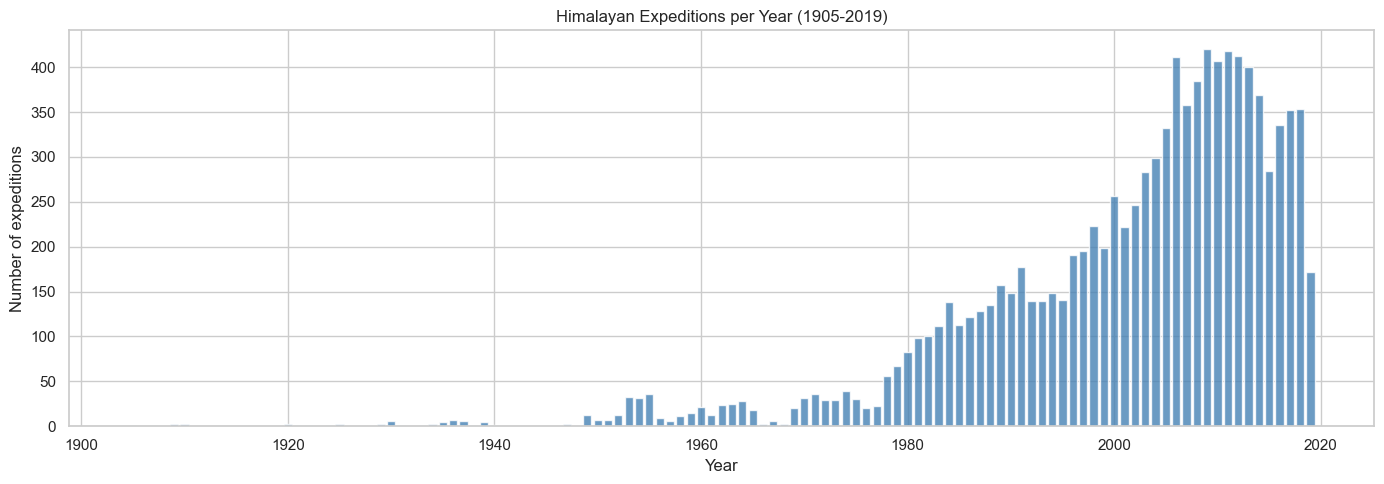

In [8]:
exp_per_year = expeditions.groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(exp_per_year.index, exp_per_year.values, color='steelblue', alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of expeditions')
ax.set_title('Himalayan Expeditions per Year (1905-2019)')
plt.tight_layout()
plt.show()

### 4. Expeditions by season

In [ ]:
expeditions[expeditions["season"] == "Unknown"].shape[0]

2

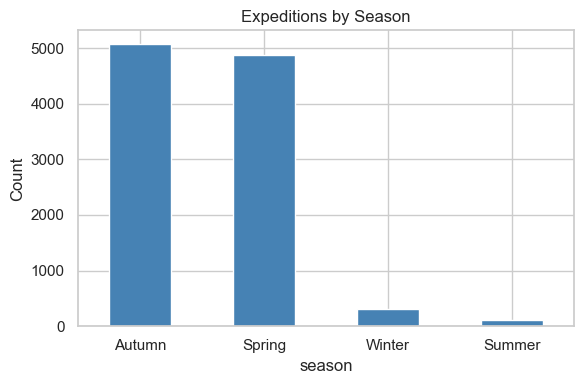

In [ ]:
# There are 2 expeditions with an undefined season ("Unknown").
# Since this is negligible, we exclude them from the visualization to avoid noise.

season_counts = expeditions[expeditions["season"] != "Unknown"]["season"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
season_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Expeditions by Season')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Most popular peaks

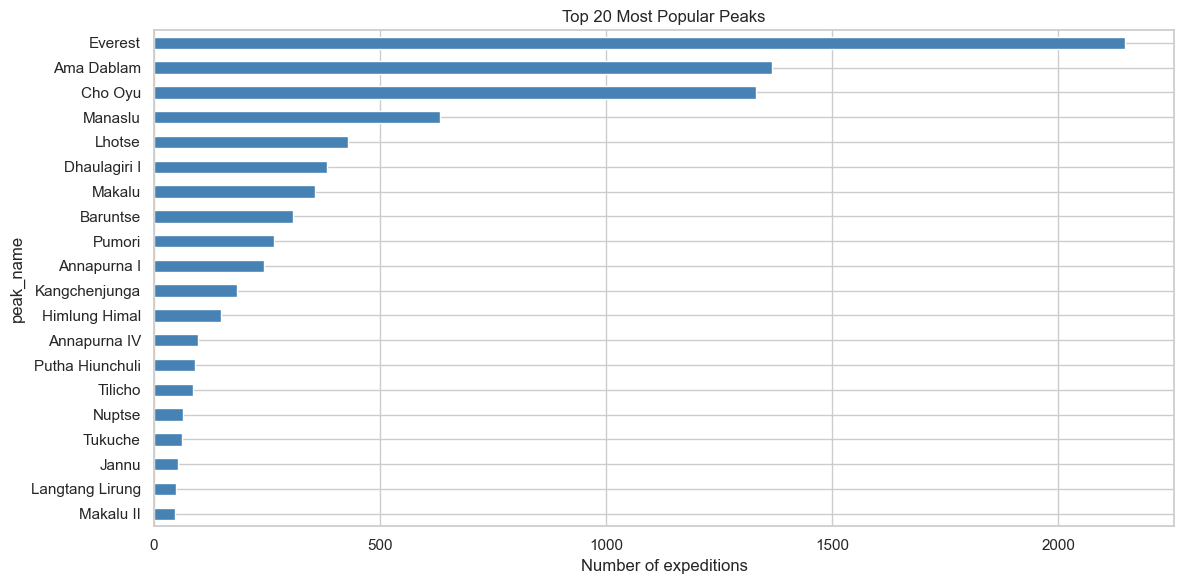

In [8]:
top_peaks = expeditions.peak_name.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_peaks.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of expeditions')
ax.set_title('Top 20 Most Popular Peaks')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 6. Success and failure rates over time

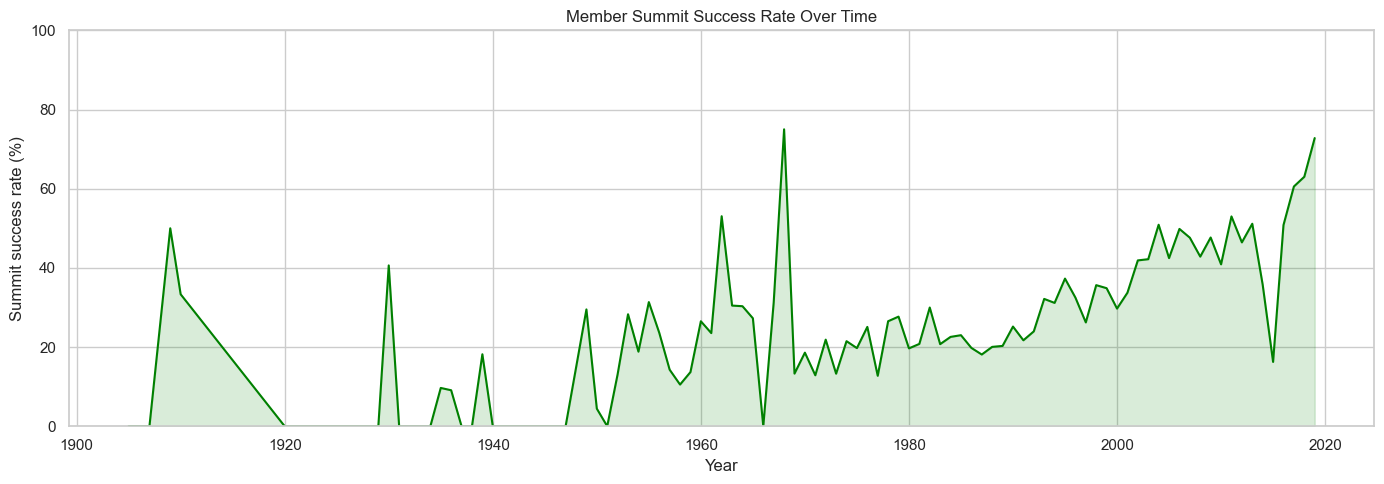

In [9]:
# Success rate per member over time
success_by_year = members.groupby('year').agg(
    total=('success', 'count'),
    successes=('success', 'sum')
).reset_index()
success_by_year['rate'] = success_by_year['successes'] / success_by_year['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(success_by_year.year, success_by_year.rate, color='green', linewidth=1.5)
ax.fill_between(success_by_year.year, success_by_year.rate, alpha=0.15, color='green')
ax.set_xlabel('Year')
ax.set_ylabel('Summit success rate (%)')
ax.set_title('Member Summit Success Rate Over Time')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [10]:
# Termination reasons
term_reasons = expeditions.termination_reason.value_counts()
print('Termination reasons:')
print(term_reasons)

Termination reasons:
termination_reason
Success (main peak)                                                             5581
Bad weather (storms, high winds)                                                1307
Bad conditions (deep snow, avalanching, falling ice, or rock)                   1097
Illness, AMS, exhaustion, or frostbite                                           458
Route technically too difficult, lack of experience, strength, or motivation     438
Other                                                                            320
Accident (death or serious injury)                                               299
Did not attempt climb                                                            233
Lack (or loss) of supplies or equipment                                          220
Success (subpeak)                                                                126
Unknown                                                                           96
Lack of time             

### 7. Death rates over time

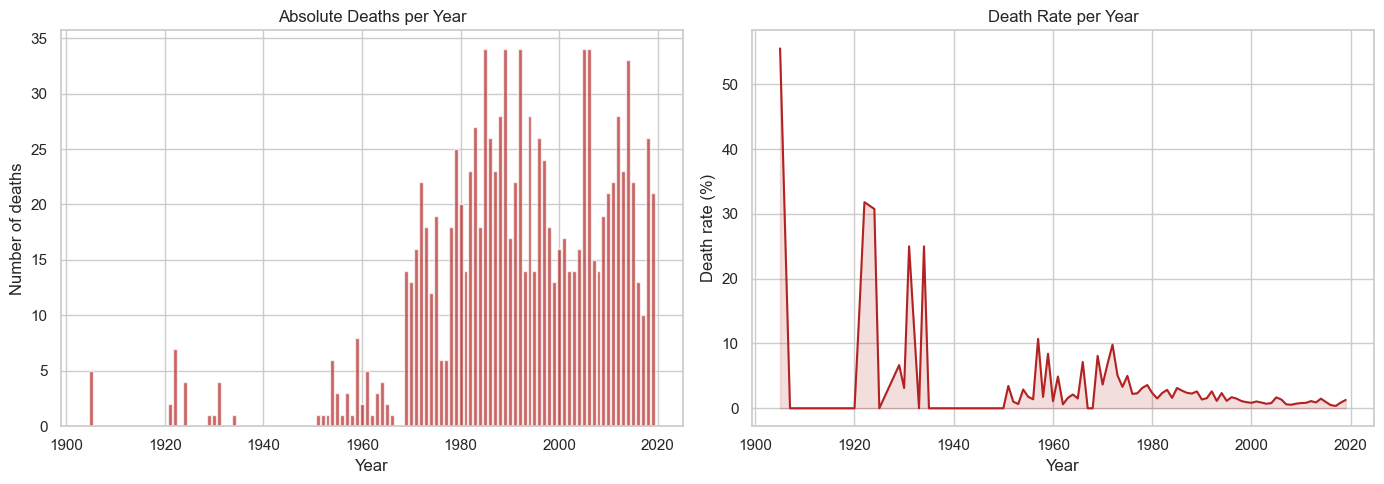

Total deaths: 1106
Overall death rate: 1.45%


In [11]:
death_by_year = members.groupby('year').agg(
    total=('died', 'count'),
    deaths=('died', 'sum')
).reset_index()
death_by_year['rate'] = death_by_year['deaths'] / death_by_year['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(death_by_year.year, death_by_year.deaths, color='firebrick', alpha=0.7)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of deaths')
axes[0].set_title('Absolute Deaths per Year')

axes[1].plot(death_by_year.year, death_by_year.rate, color='firebrick', linewidth=1.5)
axes[1].fill_between(death_by_year.year, death_by_year.rate, alpha=0.15, color='firebrick')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Death rate (%)')
axes[1].set_title('Death Rate per Year')

plt.tight_layout()
plt.show()

print(f'Total deaths: {members.died.sum()}')
print(f'Overall death rate: {members.died.mean()*100:.2f}%')

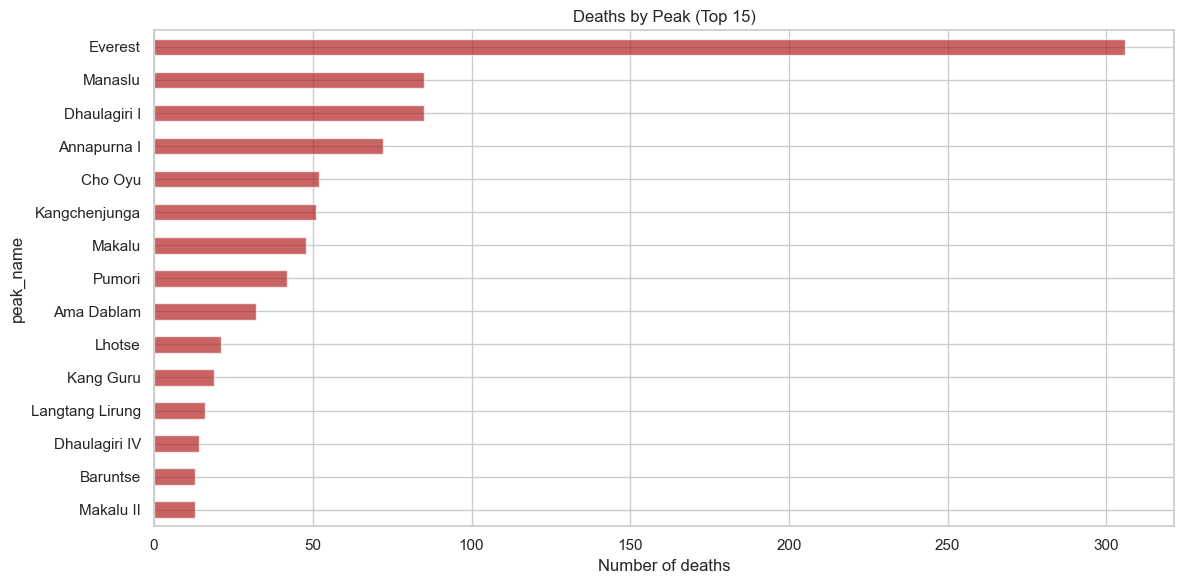

In [12]:
# Deaths by peak (top 15)
deaths_by_peak = members[members.died].peak_name.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
deaths_by_peak.plot(kind='barh', ax=ax, color='firebrick', alpha=0.7)
ax.set_xlabel('Number of deaths')
ax.set_title('Deaths by Peak (Top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

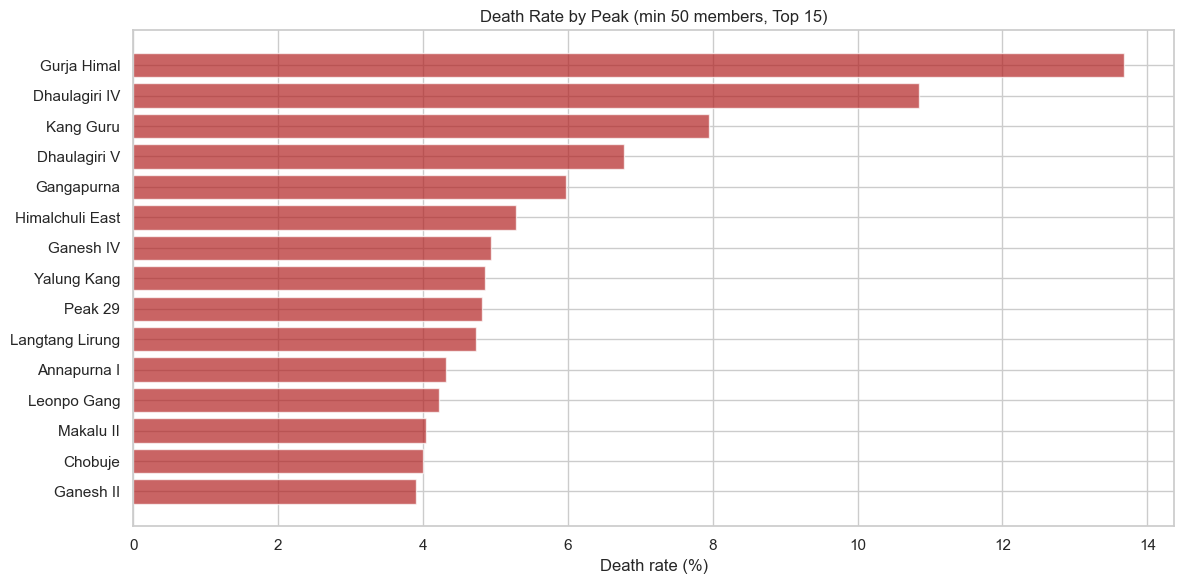

In [13]:
# Death rate by peak (peaks with at least 50 members)
peak_stats = members.groupby('peak_name').agg(
    total=('died', 'count'),
    deaths=('died', 'sum')
).reset_index()
peak_stats['death_rate'] = peak_stats['deaths'] / peak_stats['total'] * 100
peak_stats_filtered = peak_stats[peak_stats.total >= 50].sort_values('death_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(peak_stats_filtered.peak_name, peak_stats_filtered.death_rate, color='firebrick', alpha=0.7)
ax.set_xlabel('Death rate (%)')
ax.set_title('Death Rate by Peak (min 50 members, Top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 8. Death causes

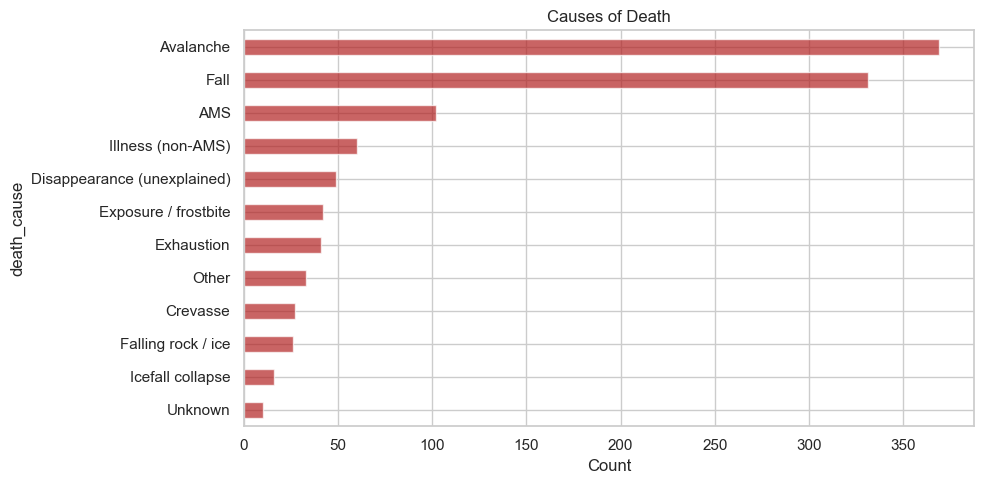

In [14]:
death_causes = members[members.died].death_cause.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
death_causes.plot(kind='barh', ax=ax, color='firebrick', alpha=0.7)
ax.set_xlabel('Count')
ax.set_title('Causes of Death')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 9. Nationality breakdown

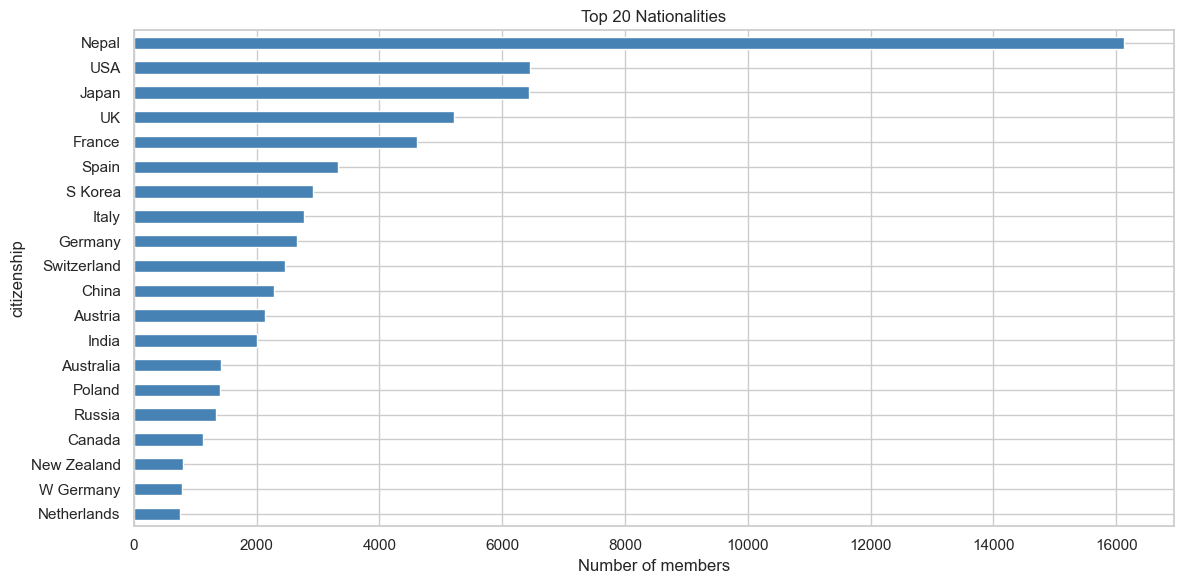

In [15]:
top_countries = members.citizenship.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of members')
ax.set_title('Top 20 Nationalities')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

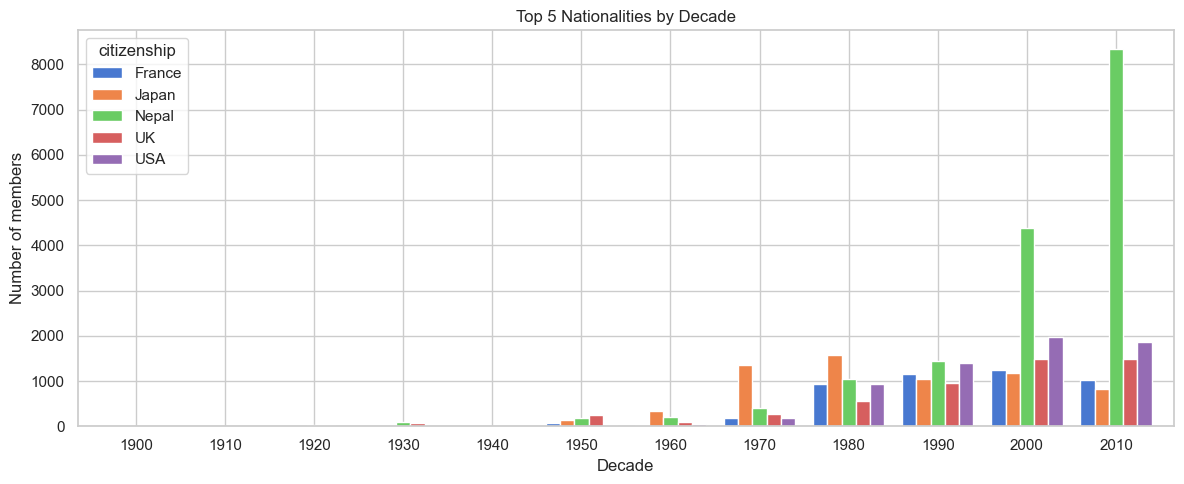

In [16]:
# Nationality evolution over time (top 5 countries, per decade)
members_copy = members.copy()
members_copy['decade'] = (members_copy.year // 10) * 10
top5 = members_copy.citizenship.value_counts().head(5).index

country_decade = members_copy[members_copy.citizenship.isin(top5)].groupby(['decade', 'citizenship']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
country_decade.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Decade')
ax.set_ylabel('Number of members')
ax.set_title('Top 5 Nationalities by Decade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10. Oxygen usage trends

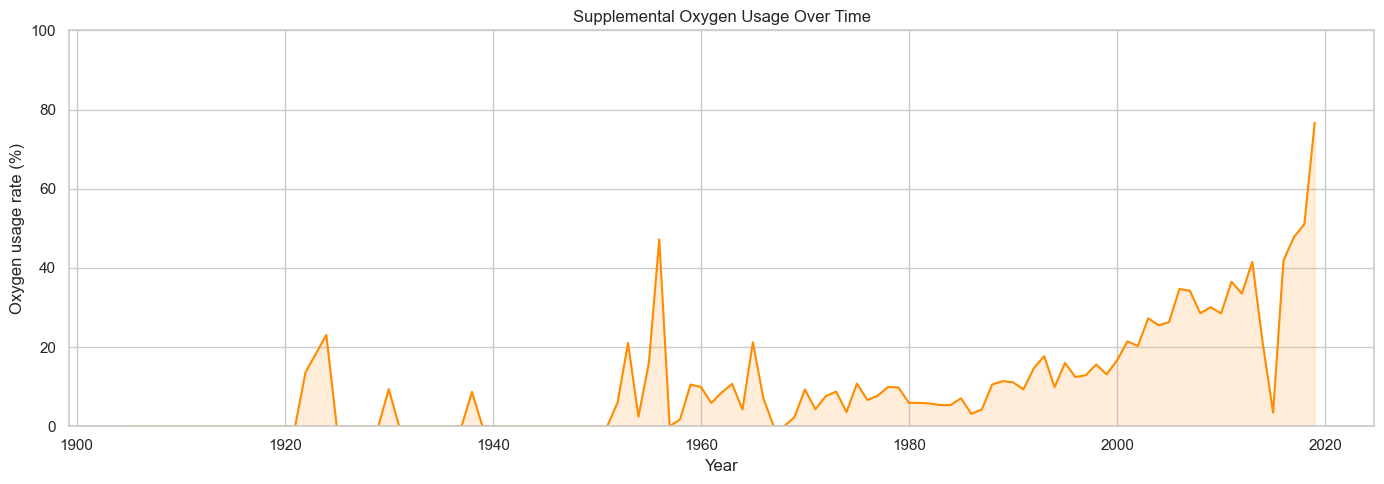

In [17]:
# Oxygen usage over time (members)
oxy_by_year = members.groupby('year').agg(
    total=('oxygen_used', 'count'),
    oxygen_yes=('oxygen_used', 'sum')
).reset_index()
oxy_by_year['rate'] = oxy_by_year['oxygen_yes'] / oxy_by_year['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(oxy_by_year.year, oxy_by_year.rate, color='darkorange', linewidth=1.5)
ax.fill_between(oxy_by_year.year, oxy_by_year.rate, alpha=0.15, color='darkorange')
ax.set_xlabel('Year')
ax.set_ylabel('Oxygen usage rate (%)')
ax.set_title('Supplemental Oxygen Usage Over Time')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [18]:
# Oxygen and success: does it help?
oxy_success = members.groupby('oxygen_used').agg(
    total=('success', 'count'),
    successes=('success', 'sum'),
    deaths=('died', 'sum')
).reset_index()
oxy_success['success_rate'] = oxy_success['successes'] / oxy_success['total'] * 100
oxy_success['death_rate'] = oxy_success['deaths'] / oxy_success['total'] * 100
print('Oxygen usage vs success/death:')
print(oxy_success)

Oxygen usage vs success/death:
   oxygen_used  total  successes  deaths  success_rate  death_rate
0        False  58286      15068     899     25.851834    1.542394
1         True  18233      14131     207     77.502331    1.135304


### 11. Hired staff (Sherpas) analysis

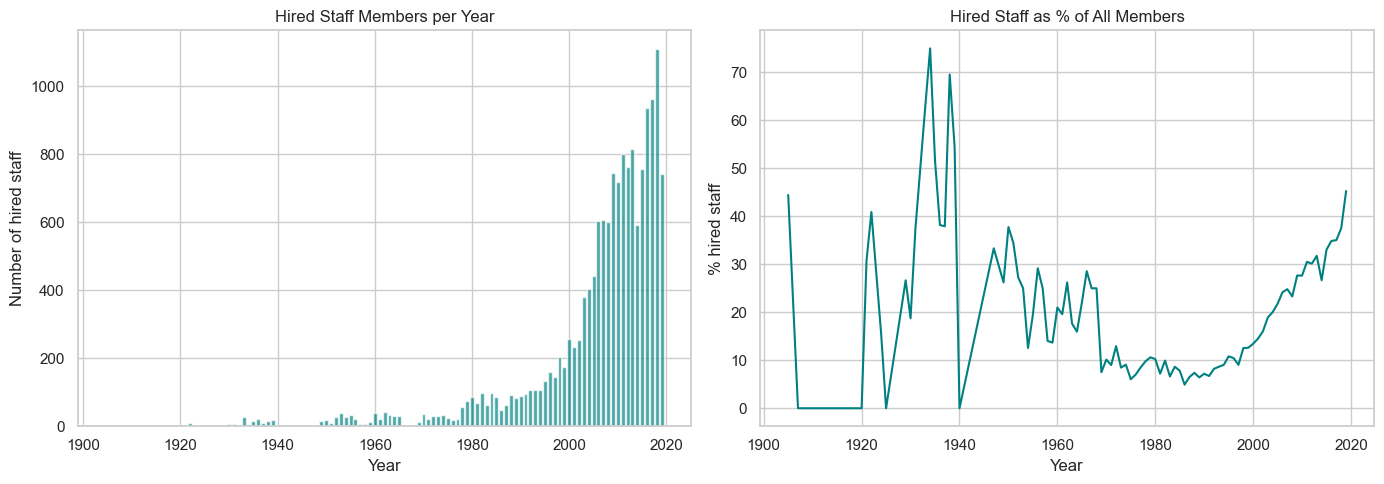

In [19]:
# Hired staff participation over time
hired_by_year = members.groupby('year').agg(
    total=('hired', 'count'),
    hired_count=('hired', 'sum')
).reset_index()
hired_by_year['rate'] = hired_by_year['hired_count'] / hired_by_year['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hired_by_year.year, hired_by_year.hired_count, color='teal', alpha=0.7)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of hired staff')
axes[0].set_title('Hired Staff Members per Year')

axes[1].plot(hired_by_year.year, hired_by_year.rate, color='teal', linewidth=1.5)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% hired staff')
axes[1].set_title('Hired Staff as % of All Members')

plt.tight_layout()
plt.show()

In [20]:
# Death rate: hired vs non-hired
hired_deaths = members.groupby('hired').agg(
    total=('died', 'count'),
    deaths=('died', 'sum')
).reset_index()
hired_deaths['death_rate'] = hired_deaths['deaths'] / hired_deaths['total'] * 100
print('Death rates by hired status:')
print(hired_deaths)

Death rates by hired status:
   hired  total  deaths  death_rate
0  False  60788     788    1.296308
1   True  15731     318    2.021486


### 12. Commercialization: team size and trekking agencies

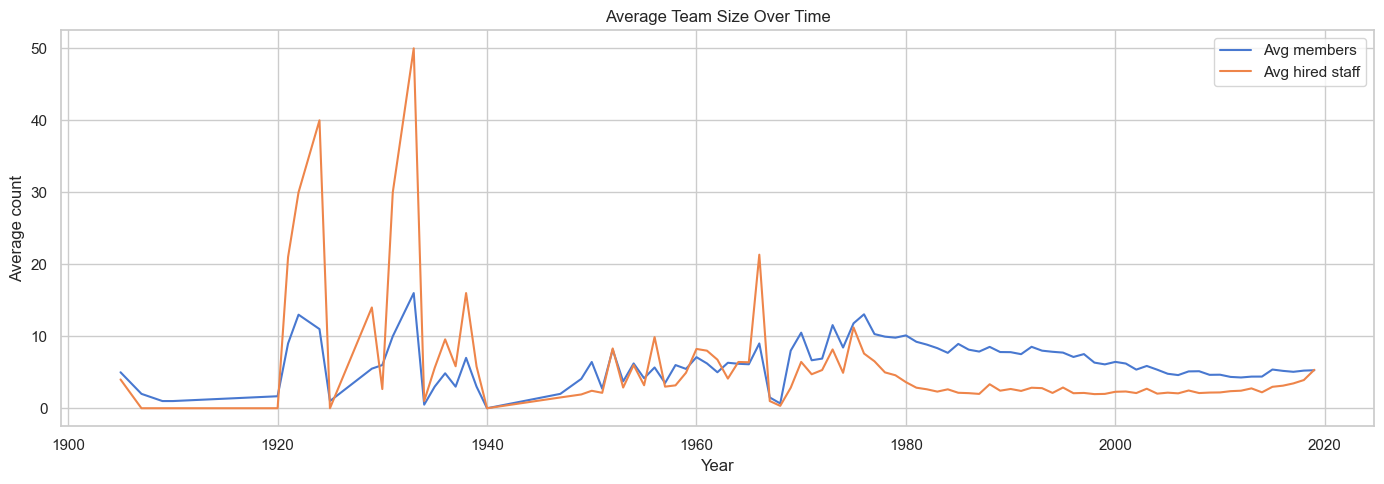

In [21]:
# Average team size over time
team_size = expeditions.groupby('year').agg(
    avg_members=('members', 'mean'),
    avg_hired=('hired_staff', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(team_size.year, team_size.avg_members, label='Avg members', linewidth=1.5)
ax.plot(team_size.year, team_size.avg_hired, label='Avg hired staff', linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Average count')
ax.set_title('Average Team Size Over Time')
ax.legend()
plt.tight_layout()
plt.show()

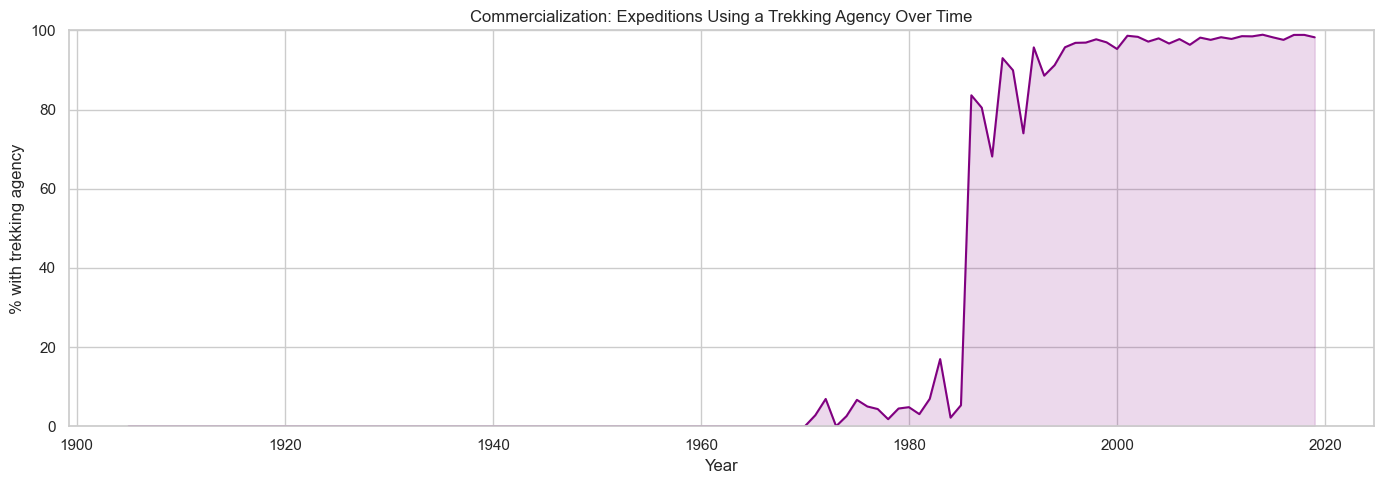

In [22]:
# Trekking agencies: how many expeditions use one?
expeditions['has_agency'] = expeditions.trekking_agency.notna()
agency_by_year = expeditions.groupby('year').agg(
    total=('has_agency', 'count'),
    with_agency=('has_agency', 'sum')
).reset_index()
agency_by_year['rate'] = agency_by_year['with_agency'] / agency_by_year['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(agency_by_year.year, agency_by_year.rate, color='purple', linewidth=1.5)
ax.fill_between(agency_by_year.year, agency_by_year.rate, alpha=0.15, color='purple')
ax.set_xlabel('Year')
ax.set_ylabel('% with trekking agency')
ax.set_title('Commercialization: Expeditions Using a Trekking Agency Over Time')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

### 13. Age and gender distribution

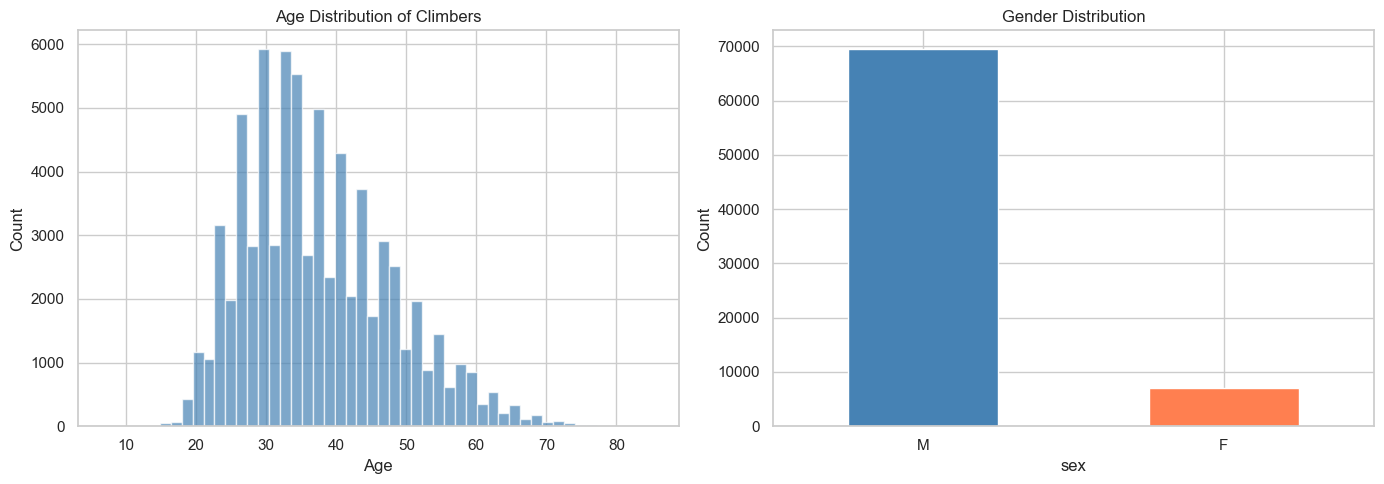

Female %: 9.2%
Mean age: 37.3, Median: 36


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
members.age.dropna().hist(bins=50, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution of Climbers')

# Gender split
gender = members.sex.value_counts()
gender.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f'Female %: {(members.sex == "F").mean()*100:.1f}%')
print(f'Mean age: {members.age.mean():.1f}, Median: {members.age.median():.0f}')

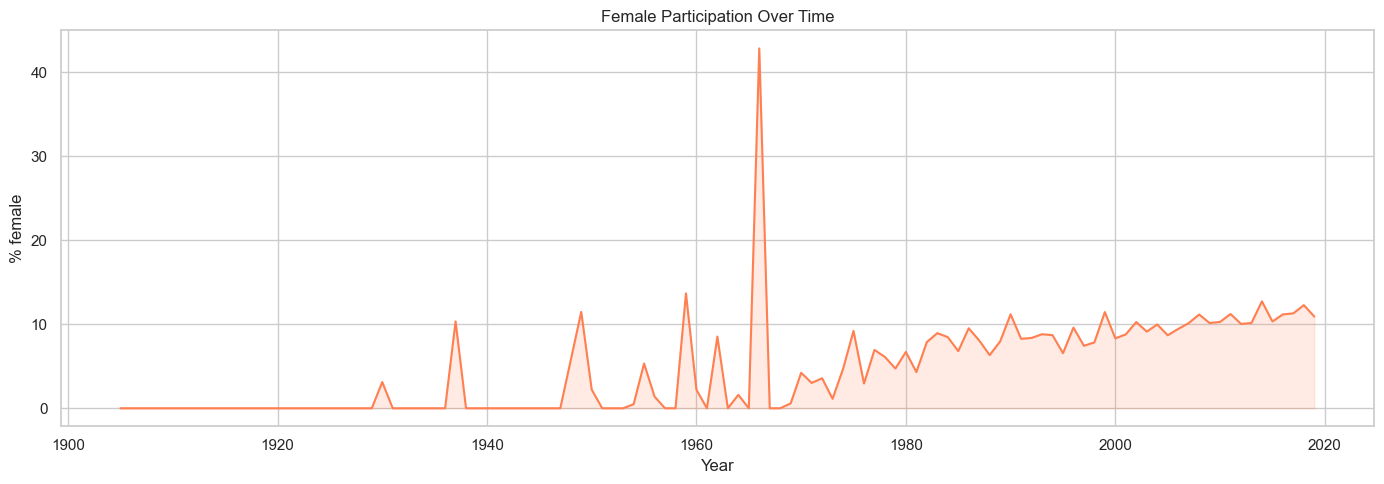

In [24]:
# Female participation over time
gender_year = members.groupby('year').agg(
    total=('sex', 'count'),
    female=('sex', lambda x: (x == 'F').sum())
).reset_index()
gender_year['female_pct'] = gender_year['female'] / gender_year['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gender_year.year, gender_year.female_pct, color='coral', linewidth=1.5)
ax.fill_between(gender_year.year, gender_year.female_pct, alpha=0.15, color='coral')
ax.set_xlabel('Year')
ax.set_ylabel('% female')
ax.set_title('Female Participation Over Time')
plt.tight_layout()
plt.show()

### 14. Everest deep dive

Everest members: 21813
Everest summits: 10036
Everest deaths: 306
Everest success rate: 46.0%
Everest death rate: 1.40%


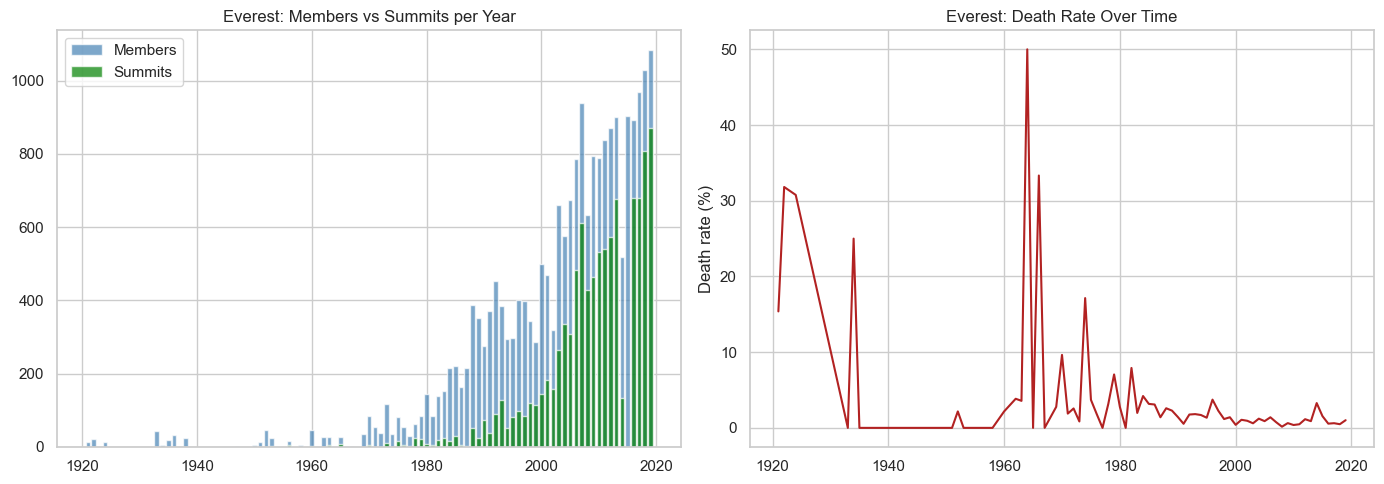

In [25]:
everest = members[members.peak_name == 'Everest']
print(f'Everest members: {len(everest)}')
print(f'Everest summits: {everest.success.sum()}')
print(f'Everest deaths: {everest.died.sum()}')
print(f'Everest success rate: {everest.success.mean()*100:.1f}%')
print(f'Everest death rate: {everest.died.mean()*100:.2f}%')

everest_year = everest.groupby('year').agg(
    members=('success', 'count'),
    summits=('success', 'sum'),
    deaths=('died', 'sum')
).reset_index()
everest_year['success_rate'] = everest_year['summits'] / everest_year['members'] * 100
everest_year['death_rate'] = everest_year['deaths'] / everest_year['members'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(everest_year.year, everest_year.members, color='steelblue', alpha=0.7, label='Members')
axes[0].bar(everest_year.year, everest_year.summits, color='green', alpha=0.7, label='Summits')
axes[0].set_title('Everest: Members vs Summits per Year')
axes[0].legend()

axes[1].plot(everest_year.year, everest_year.death_rate, color='firebrick', linewidth=1.5)
axes[1].set_title('Everest: Death Rate Over Time')
axes[1].set_ylabel('Death rate (%)')

plt.tight_layout()
plt.show()

### 15. Summary of key findings

Possible insights to research and include in the visuals:

1. Explosive growth: Expeditions exploded from ~10/year in the 1970s to 400+/year by 2019
2. Spring dominance: ~60% of expeditions happen in spring (Autumn is second)
3. Everest dominance: Everest alone accounts for a disproportionate share of expeditions and members
4. Commercialization: Trekking agency usage increased dramatically from the 1990s onward
5. Success rates up: Summit success rates have increased steadily, especially post-2000
6. Death rate down, absolute deaths up: The per-person death rate has declined, but more people means deaths still happen regularly
7. Avalanche is the top killer, followed by falls and altitude sickness
8. Hired staff face higher death rates than paying members
9. Oxygen debate: Oxygen usage correlates with higher success AND lower death rates, but masks the ethical and sporting debate
10. Gender gap: Still under 10% female, but growing slowly
11. Age: Mean age ~35, but range is wide (16-85)